In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Загрузка
df = pd.read_csv('mushrooms.csv')

# Проверка на пропуски
print(df.isnull().sum().sum()) # Обычно их 0

# Кодирование признаков (перевод букв в цифры)
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le




def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Edible', 'Poisonous']).plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()



0


--- Logistic Regression ---
Accuracy:  0.9477
Precision: 0.9439
Recall:    0.9476
F1-score:  0.9458
AUC-ROC:   0.9806


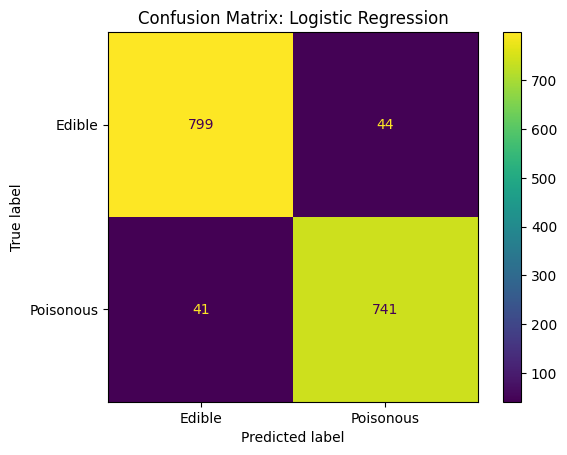

--- Decision Tree ---
Accuracy:  0.9520
Precision: 0.9282
Recall:    0.9757
F1-score:  0.9514
AUC-ROC:   0.9831


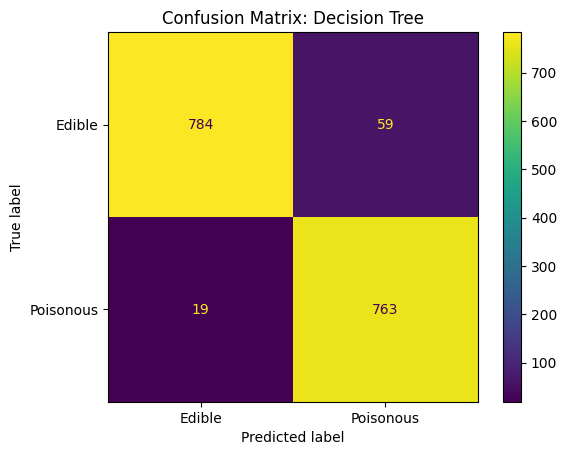

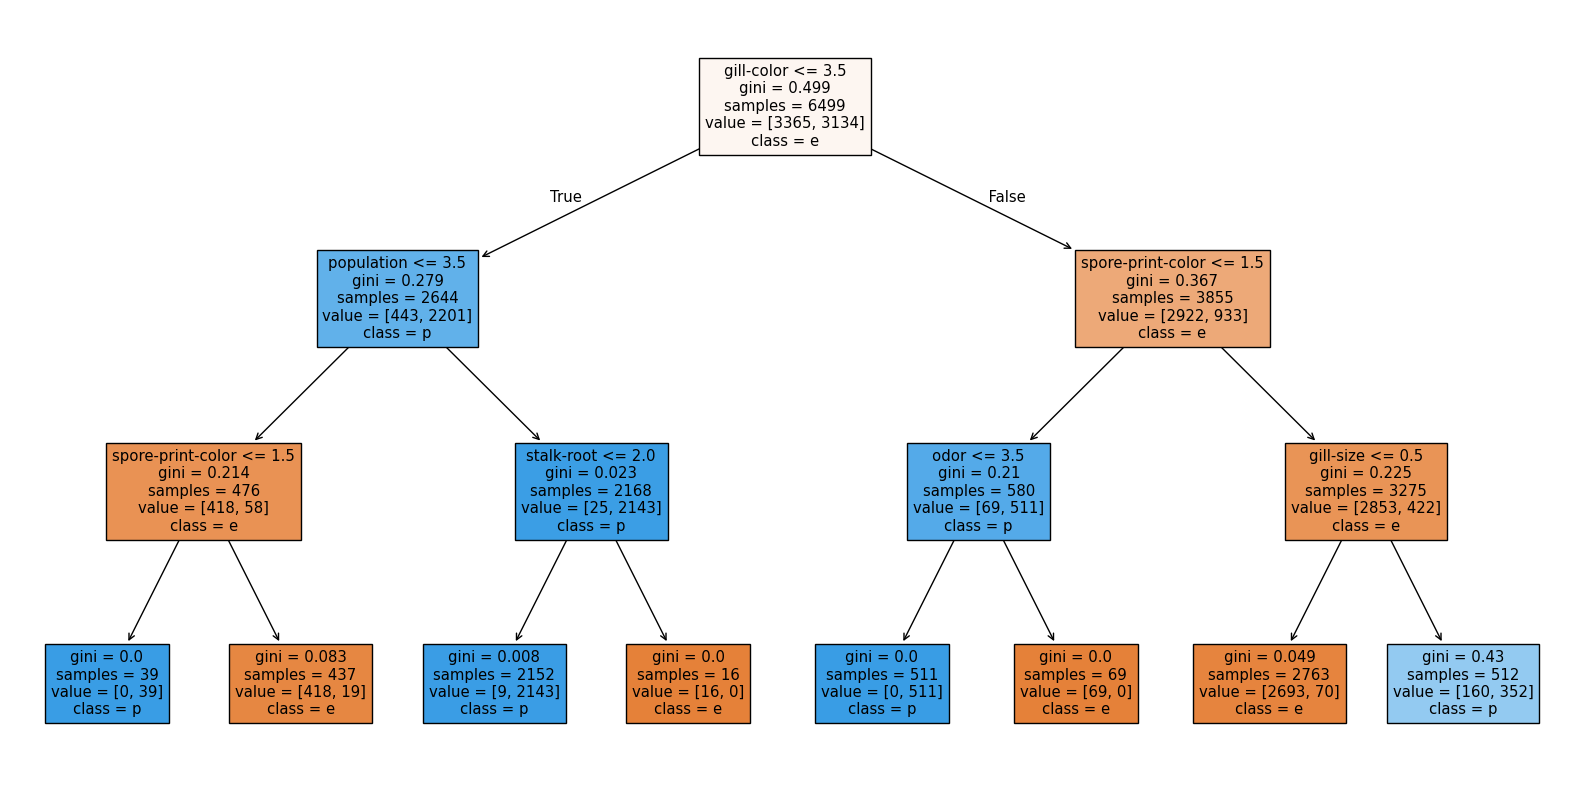

--- Random Forest ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
AUC-ROC:   1.0000


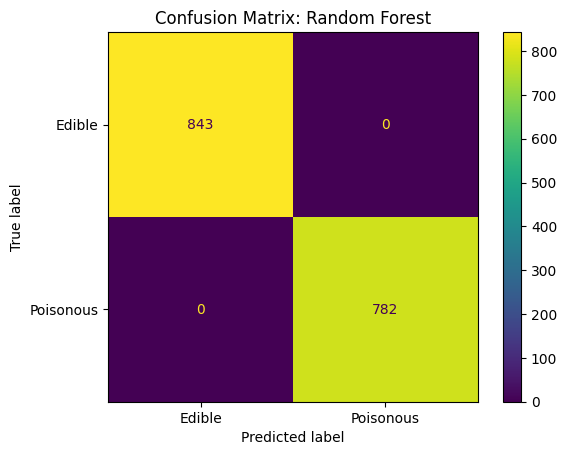

In [8]:
# 1 
# poisonous or eatable

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop('class', axis=1)
y = df['class']
# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 1. Логистическая регрессия
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
evaluate_model(lr, X_test, y_test, "Logistic Regression")

# 2. Дерево решений + Визуализация
dt = DecisionTreeClassifier(max_depth=3) # Ограничим глубину для красоты визуализации
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test, "Decision Tree")

# Визуализация дерева
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['e', 'p'], filled=True)
plt.show()

# 3. Случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, "Random Forest")


/home/usercommon/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy:  0.6468
Precision: 0.6356
Recall:    0.6468
F1-score:  0.6355
AUC-ROC:   0.9462


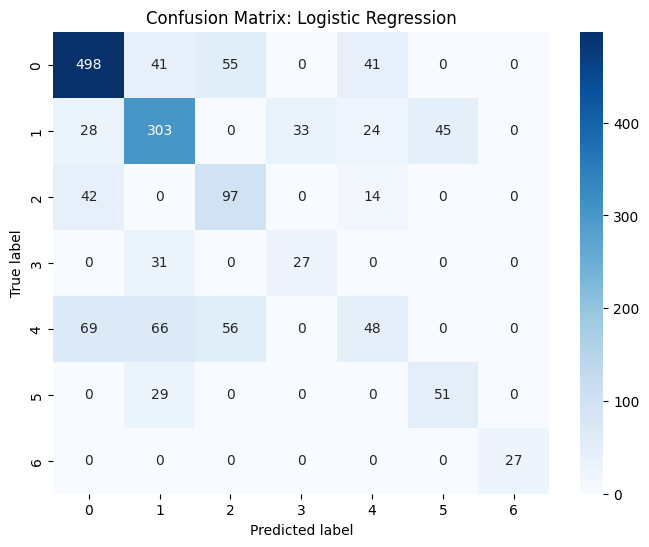


--- Decision Tree ---
Accuracy:  0.6400
Precision: 0.5941
Recall:    0.6400
F1-score:  0.5993
AUC-ROC:   0.9422


/home/usercommon/machine_learning/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


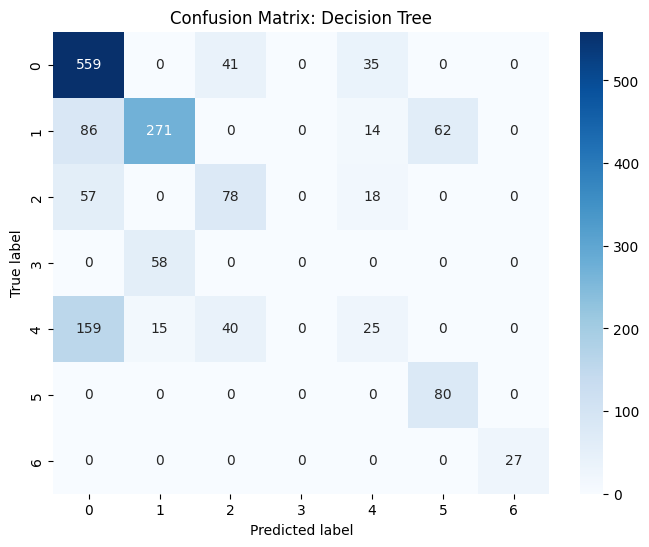


--- Random Forest ---
Accuracy:  0.4782
Precision: 0.4771
Recall:    0.4782
F1-score:  0.4774
AUC-ROC:   0.9013


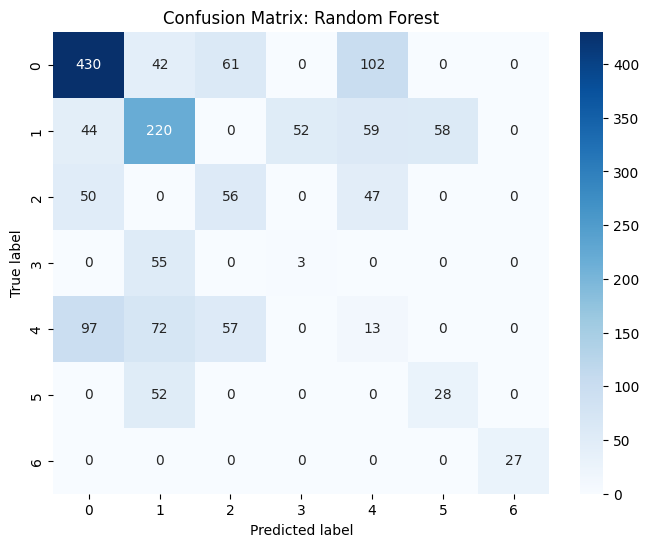


--- Gradient Boosting ---
Accuracy:  0.5914
Precision: 0.5951
Recall:    0.5914
F1-score:  0.5917
AUC-ROC:   0.9345


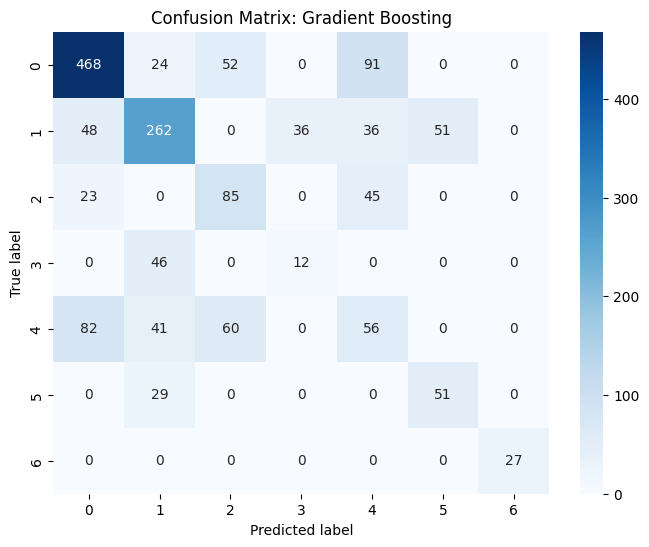


--- Naive Bayes ---
Accuracy:  0.5366
Precision: 0.7844
Recall:    0.5366
F1-score:  0.5500
AUC-ROC:   0.8792


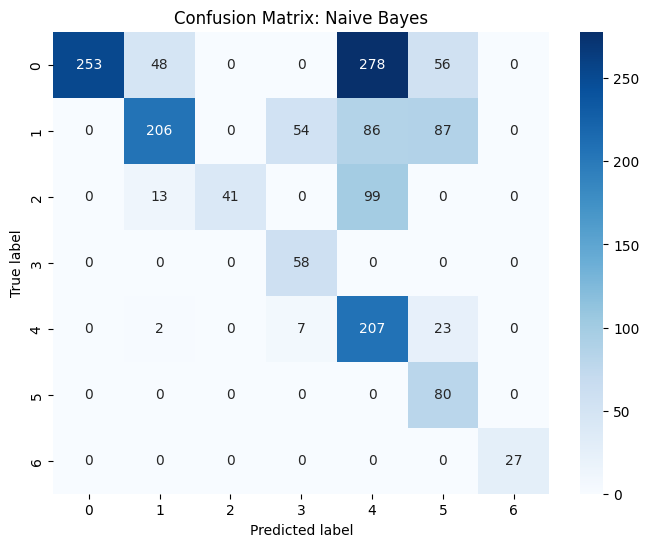

In [10]:
# 2
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Подготовка данных
# Теперь целевая переменная - 'habitat'
X_hab = df.drop('habitat', axis=1)
y_hab = df['habitat']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hab, y_hab, test_size=0.2, random_state=42)

# Функция для оценки многоклассовой классификации
def evaluate_multi(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    # Для многоклассовости используем weighted усреднение
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
    # AUC-ROC для нескольких классов
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba, multi_class='ovr'):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# --- Обучение моделей ---

# 1. Логистическая регрессия (для мультикласса сама включит multinomial)
lr_h = LogisticRegression(max_iter=1000)
lr_h.fit(X_train_h, y_train_h)
evaluate_multi(lr_h, X_test_h, y_test_h, "Logistic Regression")

# 2. Дерево решений
dt_h = DecisionTreeClassifier(max_depth=5)
dt_h.fit(X_train_h, y_train_h)
evaluate_multi(dt_h, X_test_h, y_test_h, "Decision Tree")

# 3. Случайный лес
rf_h = RandomForestClassifier(n_estimators=100)
rf_h.fit(X_train_h, y_train_h)
evaluate_multi(rf_h, X_test_h, y_test_h, "Random Forest")

# 4. Градиентный бустинг
gb_h = GradientBoostingClassifier()
gb_h.fit(X_train_h, y_train_h)
evaluate_multi(gb_h, X_test_h, y_test_h, "Gradient Boosting")

# 5. Наивный Байес
nb_h = GaussianNB()
nb_h.fit(X_train_h, y_train_h)
evaluate_multi(nb_h, X_test_h, y_test_h, "Naive Bayes")


АНАЛИЗ ПРИЗНАКА: gill-attachment

--- Logistic Regression ---
Accuracy:  0.9975
Precision: 0.9976
Recall:    0.9975
F1-score:  0.9976
AUC-ROC:   0.9999


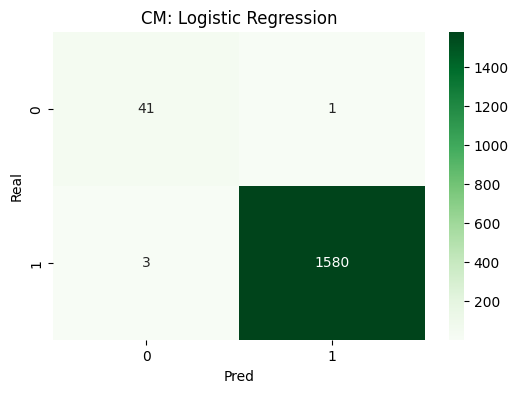


--- Decision Tree ---
Accuracy:  0.9969
Precision: 0.9970
Recall:    0.9969
F1-score:  0.9969
AUC-ROC:   0.9993


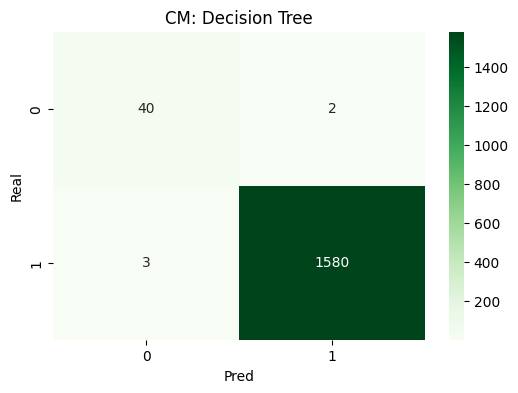


--- Random Forest ---
Accuracy:  0.9969
Precision: 0.9970
Recall:    0.9969
F1-score:  0.9969
AUC-ROC:   0.9999


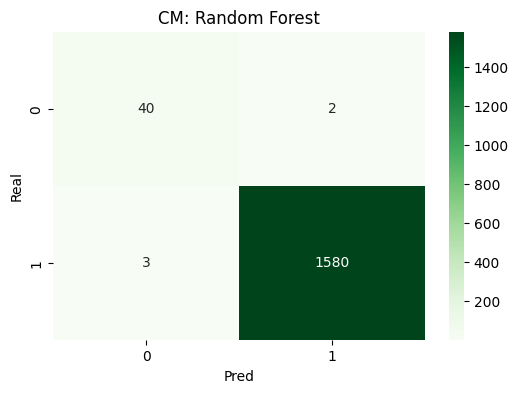


--- Gradient Boosting ---
Accuracy:  0.9969
Precision: 0.9970
Recall:    0.9969
F1-score:  0.9969
AUC-ROC:   0.9999


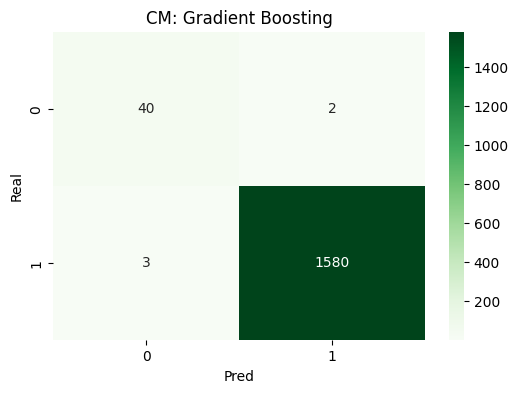


--- Naive Bayes ---
Accuracy:  0.9871
Precision: 0.9904
Recall:    0.9871
F1-score:  0.9881
AUC-ROC:   0.9988


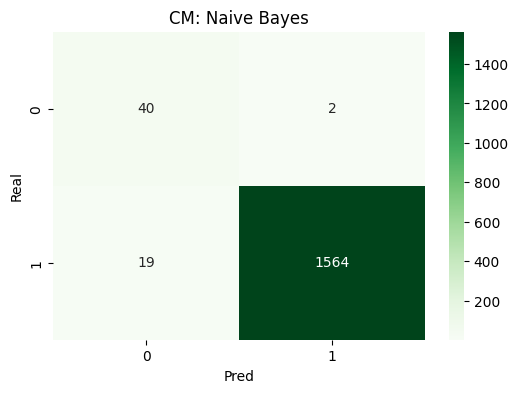


--- k-NN ---
Accuracy:  0.9969
Precision: 0.9970
Recall:    0.9969
F1-score:  0.9969
AUC-ROC:   0.9998


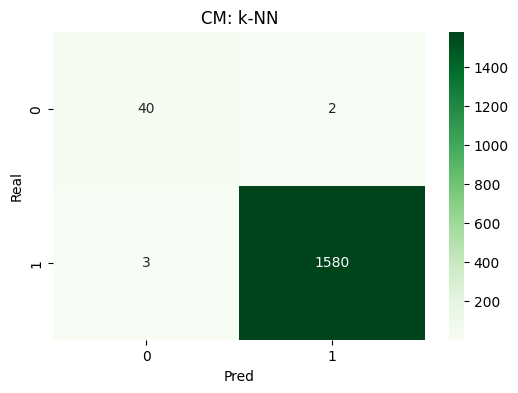


АНАЛИЗ ПРИЗНАКА: gill-spacing

--- Logistic Regression ---
Accuracy:  0.9803
Precision: 0.9802
Recall:    0.9803
F1-score:  0.9800
AUC-ROC:   0.9977


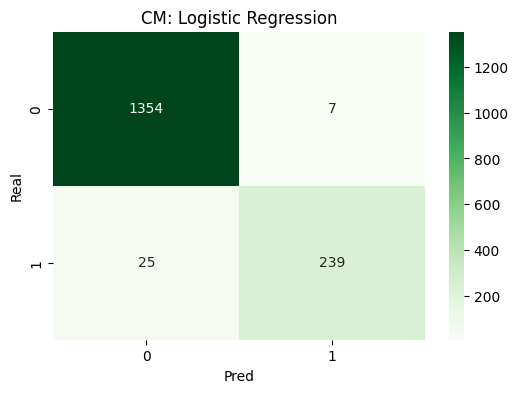


--- Decision Tree ---
Accuracy:  0.9735
Precision: 0.9733
Recall:    0.9735
F1-score:  0.9734
AUC-ROC:   0.9884


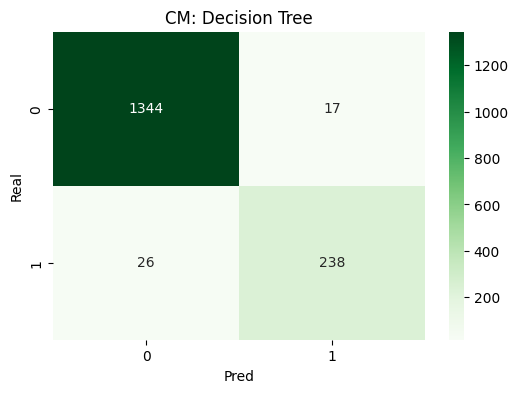


--- Random Forest ---
Accuracy:  0.9785
Precision: 0.9786
Recall:    0.9785
F1-score:  0.9785
AUC-ROC:   0.9990


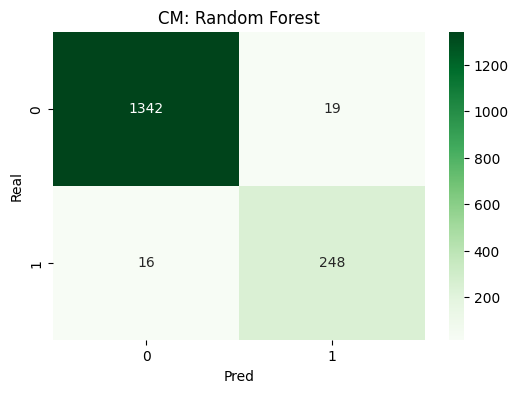


--- Gradient Boosting ---
Accuracy:  0.9895
Precision: 0.9896
Recall:    0.9895
F1-score:  0.9896
AUC-ROC:   0.9996


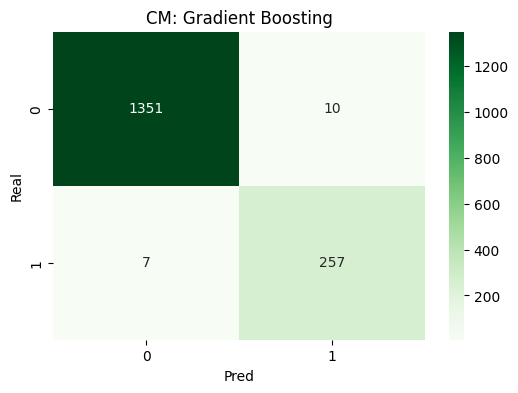


--- Naive Bayes ---
Accuracy:  0.9378
Precision: 0.9366
Recall:    0.9378
F1-score:  0.9371
AUC-ROC:   0.9660


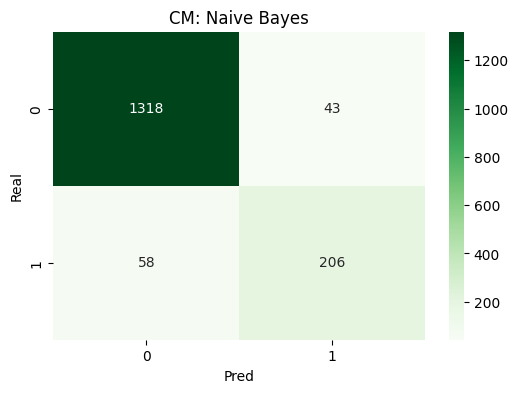


--- k-NN ---
Accuracy:  0.9791
Precision: 0.9791
Recall:    0.9791
F1-score:  0.9791
AUC-ROC:   0.9988


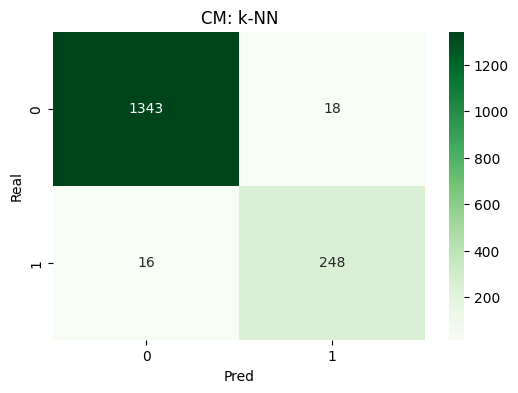


АНАЛИЗ ПРИЗНАКА: gill-size

--- Logistic Regression ---
Accuracy:  0.9920
Precision: 0.9921
Recall:    0.9920
F1-score:  0.9920
AUC-ROC:   0.9979


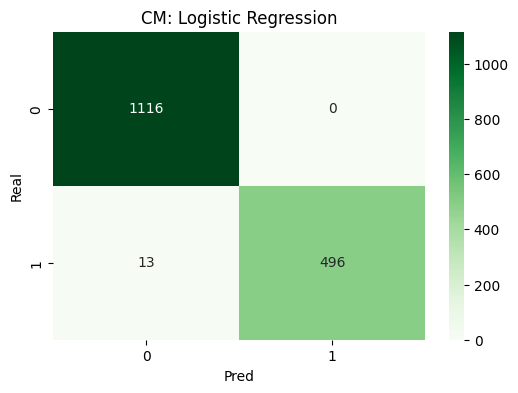


--- Decision Tree ---
Accuracy:  0.9600
Precision: 0.9622
Recall:    0.9600
F1-score:  0.9592
AUC-ROC:   0.9597


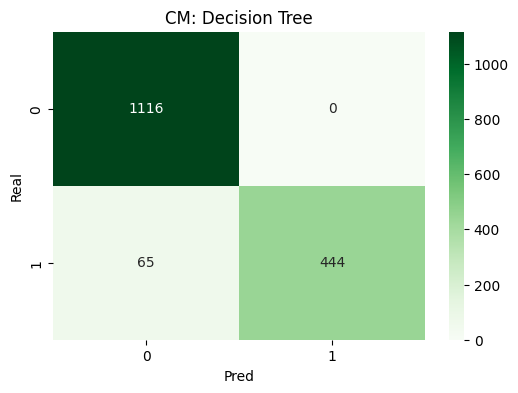


--- Random Forest ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
AUC-ROC:   1.0000


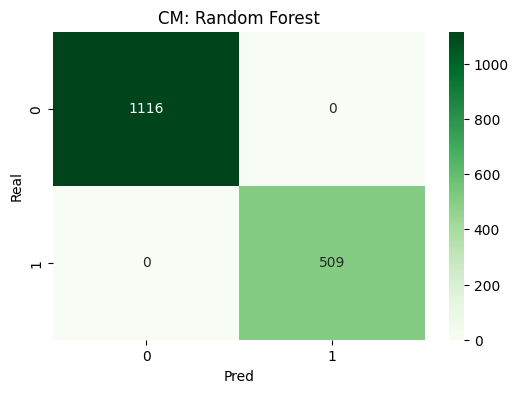


--- Gradient Boosting ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
AUC-ROC:   1.0000


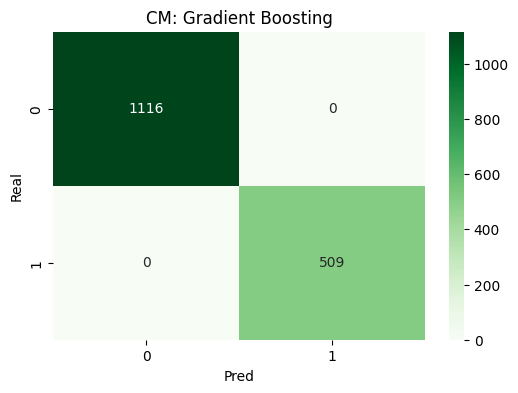


--- Naive Bayes ---
Accuracy:  0.8228
Precision: 0.8819
Recall:    0.8228
F1-score:  0.8292
AUC-ROC:   0.9673


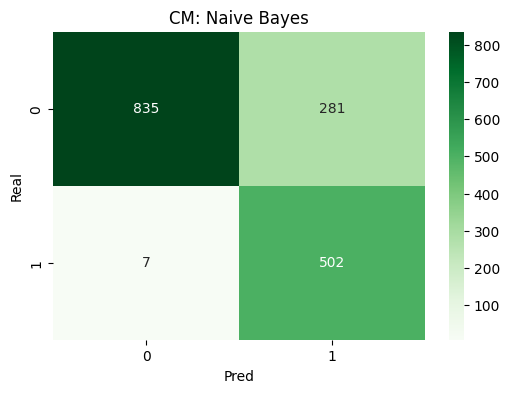


--- k-NN ---
Accuracy:  0.9994
Precision: 0.9994
Recall:    0.9994
F1-score:  0.9994
AUC-ROC:   1.0000


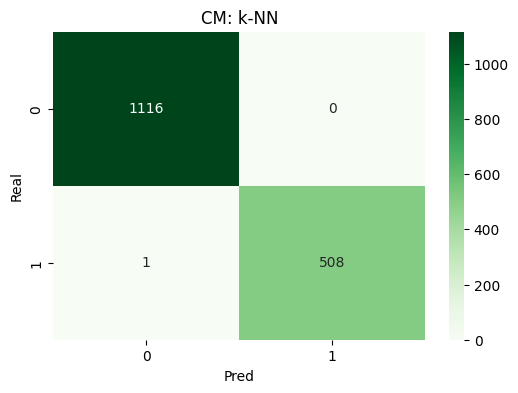

Количество уникальных комбинаций пластинок: 5

--- Combined Gill Structure (Boosting) ---
Accuracy:  0.9778
Precision: 0.9780
Recall:    0.9778
F1-score:  0.9779
AUC-ROC:   0.9992


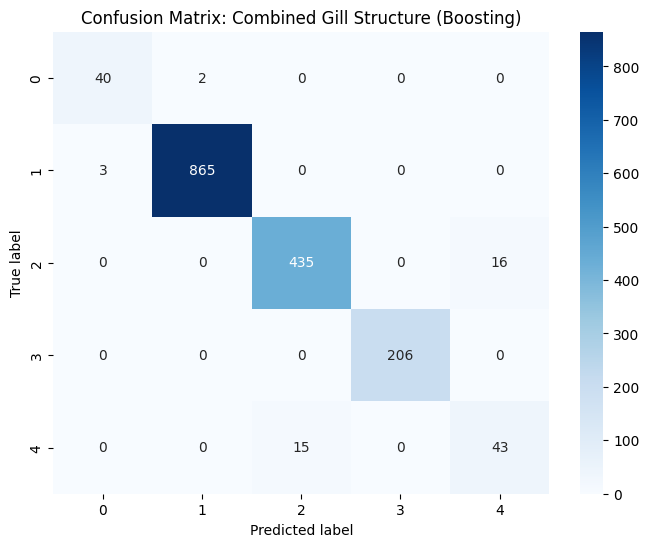

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Список целевых переменных для пластинок (Gill)
gill_targets = ['gill-attachment', 'gill-spacing', 'gill-size']

def evaluate_universal(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # Определяем количество классов
    n_classes = len(np.unique(y_test))
    
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
    
    # Расчет AUC-ROC в зависимости от количества классов
    if n_classes == 2:
        # Для бинарной берем только вторую колонку (индекс 1)
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        # Для многоклассовой используем стратегию One-vs-Rest
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    print(f"AUC-ROC:   {auc:.4f}")

    # Матрица ошибок (автоматические метки классов)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"CM: {name}")
    plt.ylabel('Real')
    plt.xlabel('Pred')
    plt.show()

def run_gill_analysis(target_name):
    print(f"\n{'='*30}\nАНАЛИЗ ПРИЗНАКА: {target_name}\n{'='*30}")
    
    # Подготовка данных
    X_g = df.drop(gill_targets, axis=1) # Убираем все три признака пластинок из X
    y_g = df[target_name]
    
    X_train, X_test, y_train, y_test = train_test_split(X_g, y_g, test_size=0.2, random_state=42)
    
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(max_depth=5),
        "Random Forest": RandomForestClassifier(n_estimators=100),
        "Gradient Boosting": GradientBoostingClassifier(),
        "Naive Bayes": GaussianNB(),
        "k-NN": KNeighborsClassifier(n_neighbors=5)
    }
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        # Используем ту же функцию evaluate_multi, что и во 2-й части
        evaluate_universal(model, X_test, y_test, name)

# Запуск по очереди
for target in gill_targets:
    run_gill_analysis(target)


# Создаем объединенный признак
df['gill_full'] = df['gill-attachment'].astype(str) + "_" + \
                  df['gill-spacing'].astype(str) + "_" + \
                  df['gill-size'].astype(str)

# Кодируем новую переменную
le_full = LabelEncoder()
df['gill_full_encoded'] = le_full.fit_transform(df['gill_full'])

print(f"Количество уникальных комбинаций пластинок: {df['gill_full'].nunique()}")

# Подготовка данных
X_full = df.drop(['gill-attachment', 'gill-spacing', 'gill-size', 'gill_full', 'gill_full_encoded'], axis=1)
y_full = df['gill_full_encoded']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Обучаем, например, Градиентный бустинг (он обычно лучший в таких задачах)
gb_full = GradientBoostingClassifier()
gb_full.fit(X_train_f, y_train_f)
evaluate_multi(gb_full, X_test_f, y_test_f, "Combined Gill Structure (Boosting)")